# Hello World - Coupled Magnetoelastic Theory
## Magnetoelastic Hysteresis

This notebook demonstrates the code used to reproduce the results in: Sablik, M.J.; Jiles, D.C., "Coupled magnetoelastic theory of magnetic and magnetostrictive hysteresis," in Magnetics, IEEE Transactions on , vol.29, no.4, pp.2113-2123, Jul 1993. 

Approximate reproduction of stress-dependent magnetization hysteresis curves
similar to the figure shown in the 1993 IEEE Transactions on Magnetics paper.

This is a practical, tunable implementation based on:
    1. Jiles–Atherton-like magnetization hysteresis
    2. Stress added through an effective field term
    3. Magnetostriction computed from magnetization


B. Howard

## Libraries

In [26]:
#import sys
#!{sys.executable} -m pip install subprocess

In [27]:
import sys
import os

# Add parent directory to path to import magnetoelasticsensor package
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

### Do the libraries we need exist?

In [28]:
import subprocess
import sys
import math

# Install required packages
required_packages = [
    'numpy',
    'pandas',
    'matplotlib',
]

print("Checking and installing required libraries...")
print("=" * 70)

for package in required_packages:
    try:
        __import__(package)
        print(f"✓ {package:12} is already installed")
    except ImportError:
        print(f"  Installing {package}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])
        print(f"✓ {package:12} installed successfully")

print("=" * 70)
print("✓ All required libraries are available!\n")

Checking and installing required libraries...
✓ numpy        is already installed
✓ pandas       is already installed
✓ matplotlib   is already installed
✓ All required libraries are available!



### Bring in the libraries

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from magnetoelasticsensor.anhyst_iso import (
    anhysteretic_magnetization,
    anhysteretic_magnetization_differential,
)
from magnetoelasticsensor.ja_solver import ja_solver

### Constants

In [30]:
MU0 = 4.0e-7 * np.pi  # H/m

### Functions

## 1. Plot the results

Computed M_an at H = 300 A/m: 144738.354822 A/m
Expected M_an from test:           144738.354822 A/m
Absolute error:                    0.000000e+00 A/m


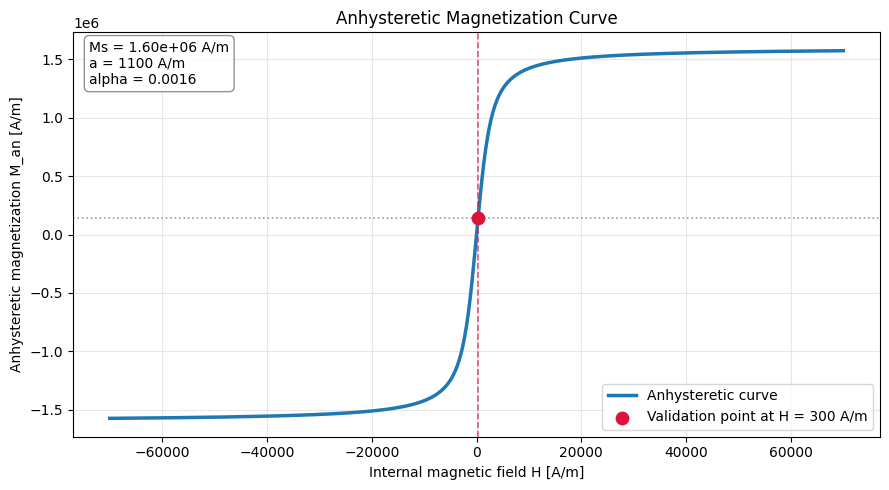

In [31]:
# Parameters from test_validate_figure03_ref02
ms = 1.6e6
m = 0.0
a = 1100
alpha = 0.0016

# Sweep the internal magnetic field to trace the anhysteretic curve
h_values = np.linspace(-70000, 70000, 801)
man_values = anhysteretic_magnetization(
    h=h_values,
    m=m,
    ms=ms,
    a=a,
    alpha=alpha,
 )

# Validation point from the unit test
h_test = 300.0
man_expected = 144738.3548215022
man_test = anhysteretic_magnetization(
    h=h_test,
    m=m,
    ms=ms,
    a=a,
    alpha=alpha,
 )

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(h_values, man_values, linewidth=2.5, label='Anhysteretic curve')
ax.scatter(
    [h_test],
    [man_test],
    color='crimson',
    s=80,
    zorder=3,
    label='Validation point at H = 300 A/m',
)
ax.axvline(h_test, color='crimson', linestyle='--', linewidth=1.2, alpha=0.7)
ax.axhline(man_expected, color='gray', linestyle=':', linewidth=1.2, alpha=0.8)

param_text = '\n'.join([
    f'Ms = {ms:.2e} A/m',
    f'a = {a:.0f} A/m',
    f'alpha = {alpha:.4f}',
])
ax.text(
    0.02,
    0.98,
    param_text,
    transform=ax.transAxes,
    fontsize=10,
    va='top',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85, edgecolor='0.5'),
)

ax.set_title('Anhysteretic Magnetization Curve')
ax.set_xlabel('Internal magnetic field H [A/m]')
ax.set_ylabel('Anhysteretic magnetization M_an [A/m]')
ax.grid(True, alpha=0.3)
ax.legend()

print(f'Computed M_an at H = {h_test:.0f} A/m: {man_test:.6f} A/m')
print(f'Expected M_an from test:           {man_expected:.6f} A/m')
print(f'Absolute error:                    {abs(man_test - man_expected):.6e} A/m')

plt.tight_layout()
plt.show()

## 2. Plot the anhysteretic derivative

Computed dM_an/dH at H = 300 A/m: 477.720139
Origin limit Ms/(3a):                     484.848485


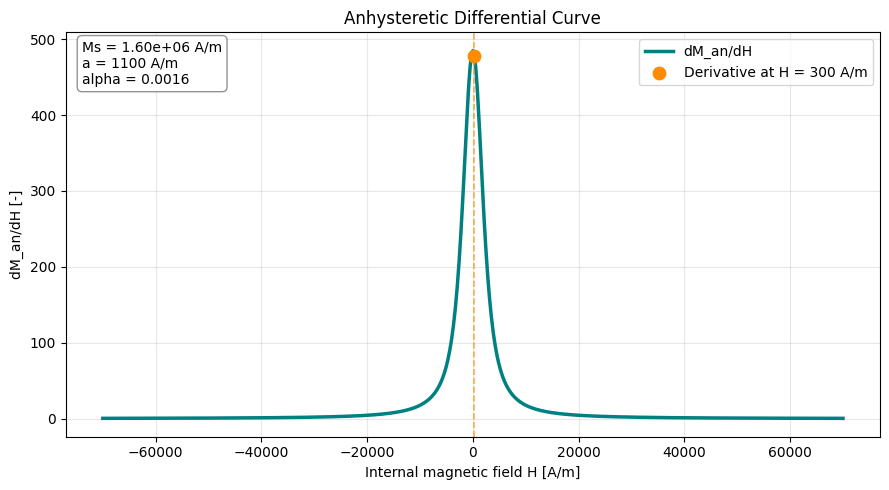

In [32]:
# Reuse the same sweep and parameters from the previous cell
h_values = np.linspace(-70000, 70000, 801)
dman_dh_values = anhysteretic_magnetization_differential(
    h=h_values,
    m=m,
    ms=ms,
    a=a,
    alpha=alpha,
)

# Validation point from dMan/dH limit and closed-form checks
h_test = 300.0
dman_dh_test = anhysteretic_magnetization_differential(
    h=h_test,
    m=m,
    ms=ms,
    a=a,
    alpha=alpha,
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(h_values, dman_dh_values, linewidth=2.5, color='teal', label='dM_an/dH')
ax.scatter(
    [h_test],
    [dman_dh_test],
    color='darkorange',
    s=80,
    zorder=3,
    label='Derivative at H = 300 A/m',
)
ax.axvline(h_test, color='darkorange', linestyle='--', linewidth=1.2, alpha=0.7)

param_text = '\n'.join([
    f'Ms = {ms:.2e} A/m',
    f'a = {a:.0f} A/m',
    f'alpha = {alpha:.4f}',
])
ax.text(
    0.02,
    0.98,
    param_text,
    transform=ax.transAxes,
    fontsize=10,
    va='top',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85, edgecolor='0.5'),
)

ax.set_title('Anhysteretic Differential Curve')
ax.set_xlabel('Internal magnetic field H [A/m]')
ax.set_ylabel('dM_an/dH [-]')
ax.grid(True, alpha=0.3)
ax.legend()

print(f'Computed dM_an/dH at H = {h_test:.0f} A/m: {dman_dh_test:.6f}')
print(f'Origin limit Ms/(3a):                     {ms / (3.0 * a):.6f}')

plt.tight_layout()
plt.show()

## 3. Plot full hysteresis loop with anhysteretic overlay

Loop points: 272
M range: [-1575.31, 1575.31] kA/m


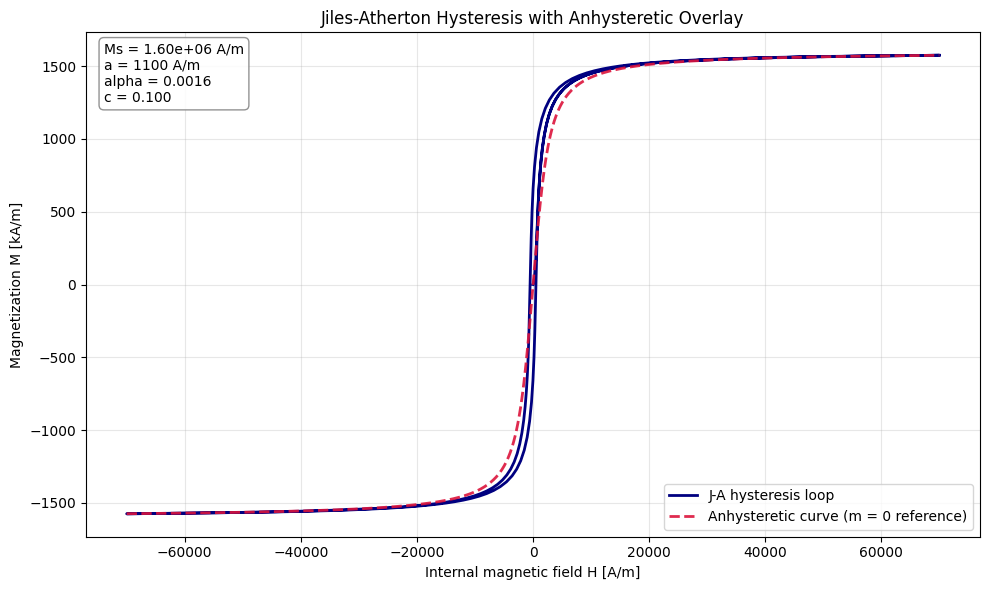

In [33]:
# Full-loop Jiles-Atherton hysteresis trajectory using ja_solver
h_max = 70000.0
solver_type = 2  # RK45
c = 0.1

# Segment 1: 0 -> +Hmax
h1, m1 = ja_solver(
    a=a,
    k=500.0,
    c=c,
    ms=ms,
    alpha=alpha,
    h_start=0.0,
    h_end=h_max,
    m0=0.0,
    solver_type=solver_type,
 )

# Segment 2: +Hmax -> -Hmax
h2, m2 = ja_solver(
    a=a,
    k=500.0,
    c=c,
    ms=ms,
    alpha=alpha,
    h_start=h_max,
    h_end=-h_max,
    m0=float(m1[-1]),
    solver_type=solver_type,
 )

# Segment 3: -Hmax -> +Hmax (close the major loop)
h3, m3 = ja_solver(
    a=a,
    k=500.0,
    c=c,
    ms=ms,
    alpha=alpha,
    h_start=-h_max,
    h_end=h_max,
    m0=float(m2[-1]),
    solver_type=solver_type,
 )

# Concatenate, removing duplicated segment boundary points
h_loop = np.concatenate([h1, h2[1:], h3[1:]])
m_loop = np.concatenate([m1, m2[1:], m3[1:]])

# Anhysteretic reference curve overlay (same H-span, m fixed to 0)
h_ref = np.linspace(-h_max, h_max, 1200)
man_ref = anhysteretic_magnetization(
    h=h_ref,
    m=0.0,
    ms=ms,
    a=a,
    alpha=alpha,
 )

# Scale magnetization to kA/m for clearer y-axis values
m_loop_ka = m_loop / 1000.0
man_ref_ka = man_ref / 1000.0

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(h_loop, m_loop_ka, color='navy', linewidth=2.0, label='J-A hysteresis loop')
ax.plot(
    h_ref,
    man_ref_ka,
    color='crimson',
    linestyle='--',
    linewidth=2.0,
    alpha=0.9,
    label='Anhysteretic curve (m = 0 reference)',
)

param_text = '\n'.join([
    f'Ms = {ms:.2e} A/m',
    f'a = {a:.0f} A/m',
    f'alpha = {alpha:.4f}',
    f'c = {c:.3f}',
])
ax.text(
    0.02,
    0.98,
    param_text,
    transform=ax.transAxes,
    fontsize=10,
    va='top',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85, edgecolor='0.5'),
)

ax.set_title('Jiles-Atherton Hysteresis with Anhysteretic Overlay')
ax.set_xlabel('Internal magnetic field H [A/m]')
ax.set_ylabel('Magnetization M [kA/m]')
ax.grid(True, alpha=0.3)
ax.legend()

print(f'Loop points: {h_loop.size}')
print(f'M range: [{np.min(m_loop_ka):.2f}, {np.max(m_loop_ka):.2f}] kA/m')

plt.tight_layout()
plt.show()